# **Métodos ensemble**

Profesor: **D.Sc. Pastor Enmanuel Pérez Estigarribia**

**CONTENIDO**

1.   Métodos voting, bagging, boosting, stacking.
2.   Aplicación de métodos ensemble con Python.

**OBJETIVOS:**


**Conceptuales**

Entender el funcionamiento de los métodos ensemble.

**Procedimentales:**

Aplicar métodos ensemble empleando Python.

**Actitudinales:**

Aprovechar las capacidades de Python para aplicar métodos ensemble.

# **Boosting: AdaBoost Ensemble en Python**

Es una clase de algoritmos de aprendizaje automático de ensemble que implica combinar las predicciones de muchos aprendices débiles (weak learners).

El algoritmo AdaBoost implica el uso de árboles de decisión muy cortos (de un nivel) como aprendices débiles que se agregan secuencialmente al conjunto. Cada modelo posterior intenta corregir las predicciones realizadas por el modelo anterior en la secuencia. Esto se logra al sopesar el conjunto de datos de entrenamiento para centrarse más en los ejemplos de entrenamiento en los que los modelos anteriores cometieron errores de predicción.

**¿Cómo se lleva a cabo el entrenamiento en el boosting?**

El método de entrenamiento varía en función del tipo de proceso de boosting denominado algoritmo de boosting. Sin embargo, un algoritmo sigue los siguientes pasos generales para entrenar el modelo de boosting:

**Paso 1**

El algoritmo de boosting asigna la misma ponderación a cada muestra de datos. Ingresa los datos al primer modelo de machine learning, llamado algoritmo base. El algoritmo base hace predicciones para cada muestra de datos.

**Paso 2**

El algoritmo de boosting evalúa las predicciones del modelo y aumenta la ponderación de las muestras que presentan un error más significativo. También asigna una ponderación basada en el rendimiento del modelo. Un modelo que genera excelentes predicciones tendrá una gran influencia sobre la decisión final.

**Paso 3**

El algoritmo pasa los datos ponderados al siguiente árbol de decisión.

**Paso 4**

El algoritmo repite los pasos 2 y 3 hasta que las instancias de errores de entrenamiento estén por debajo de cierto límite.

<img src='https://media.geeksforgeeks.org/wp-content/uploads/20210707140911/Boosting.png'>

 Fuente: https://www.geeksforgeeks.org/boosting-in-machine-learning-boosting-and-adaboost/



[**Ejemplo de asignación de pesos en arboles de deseción**](https://colab.research.google.com/drive/1-DKcdUI44Vv33218Aphyxpfek-HLUToj?usp=sharing)


## **Algoritmo de ensamble AdaBoost**

Llamamos al algoritmo AdaBoost porque, a diferencia de los algoritmos anteriores, se ajusta adaptativamente a los errores de las hipótesis débiles.

### **AdaBoost Scikit-Learn API**

AdaBoost se proporciona a través de las clases AdaBoostRegressor y AdaBoostClassifier .

Ambos modelos funcionan de la misma manera y toman los mismos argumentos que influyen en cómo se crean los árboles de decisión.

#### **AdaBoost para clasificación**

Primero, podemos usar la función make_classification() para crear un problema de clasificación binaria sintética con 1000 ejemplos y 20 características de entrada.

In [ ]:
# test classification dataset
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


A continuación, podemos evaluar un algoritmo AdaBoost en este conjunto de datos.

Evaluaremos el modelo usando validación cruzada de k-fold estratificado repetido , con tres repeticiones y 10 pliegues. Informaremos la media y la desviación estándar de la precisión del modelo en todas las repeticiones y pliegues.

In [ ]:
# evaluate adaboost algorithm for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
# define the model
model = AdaBoostClassifier()
# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

Accuracy: 0.806 (0.041)


También podemos usar el modelo AdaBoost como modelo final y hacer predicciones para la clasificación.

Primero, el conjunto AdaBoost se ajusta a todos los datos disponibles, luego se puede llamar a la función predict() para hacer predicciones sobre nuevos datos.

In [ ]:
# make predictions using adaboost for classification
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
# define the model
model = AdaBoostClassifier()
# fit the model on the whole dataset
model.fit(X, y)
# make a single prediction
row = [[-3.47224758,1.95378146,0.04875169,-0.91592588,-3.54022468,1.96405547,-7.72564954,-2.64787168,-1.81726906,-1.67104974,2.33762043,-4.30273117,0.4839841,-1.28253034,-10.6704077,-0.7641103,-3.58493721,2.07283886,0.08385173,0.91461126]]
yhat = model.predict(row)
print('Predicted Class: %d' % yhat[0])

Predicted Class: 0


### **AdaBoost para regresión**

Primero, podemos usar la función make_regression() para crear un problema de regresión sintética con 1000 ejemplos y 20 características de entrada.

El ejemplo completo se muestra a continuación.

In [ ]:
# test regression dataset
from sklearn.datasets import make_regression
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=6)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


Como hicimos en la última sección, evaluaremos el modelo usando validación cruzada repetida de k-fold, con tres repeticiones y 10 pliegues. Informaremos el error absoluto medio (MAE) del modelo en todas las repeticiones y pliegues. La biblioteca scikit-learn hace que el MAE sea negativo para que se maximice en lugar de minimizarse. Esto significa que los MAE negativos más grandes son mejores y un modelo perfecto tiene un MAE de 0.

El ejemplo completo se muestra a continuación.

In [ ]:
# evaluate adaboost ensemble for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import AdaBoostRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=6)
# define the model
model = AdaBoostRegressor()
# evaluate the model
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('MAE: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

MAE: -72.715 (4.178)


### **Hiperparámetros de AdaBoost**

Analizaremos algunos de los hiperparámetros que debe considerar ajustar para el conjunto AdaBoost y su efecto en el rendimiento del modelo.

#### **Explorar número de árboles**

Un hiperparámetro importante para el algoritmo AdaBoost es la cantidad de árboles de decisión utilizados en el conjunto.

El número de árboles se puede establecer a través del argumento "n_estimators" y el valor predeterminado es 50.

El siguiente ejemplo explora el efecto del número de árboles con valores entre 10 y 500.

>10 0.773 (0.039)
>50 0.806 (0.041)
>100 0.801 (0.032)
>500 0.793 (0.028)


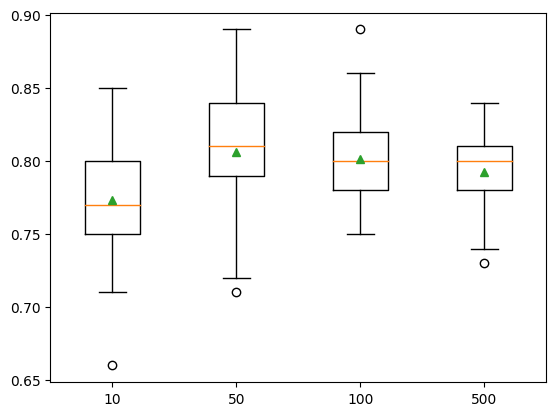

In [ ]:

# explore adaboost ensemble number of trees effect on performance
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 # define number of trees to consider
 n_trees = [10, 50, 100, 500]
 for n in n_trees:
  models[str(n)] = AdaBoostClassifier(n_estimators=n)
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model and collect the results
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 # evaluate the model
 scores = evaluate_model(model, X, y)
 # store the results
 results.append(scores)
 names.append(name)
 # summarize the performance along the way
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

#### **Explorar aprendiz débil**

Podemos hacer que los modelos utilizados en el conjunto sean menos débiles (más hábiles) aumentando la profundidad del árbol de decisión.

El siguiente ejemplo explora el efecto de aumentar la profundidad del aprendizaje débil de DecisionTreeClassifier en el conjunto de AdBoost.

>1 0.806 (0.041)
>2 0.863 (0.028)
>3 0.864 (0.032)
>4 0.890 (0.033)
>5 0.915 (0.028)
>6 0.925 (0.023)
>7 0.930 (0.022)
>8 0.931 (0.025)
>9 0.934 (0.023)
>10 0.930 (0.025)


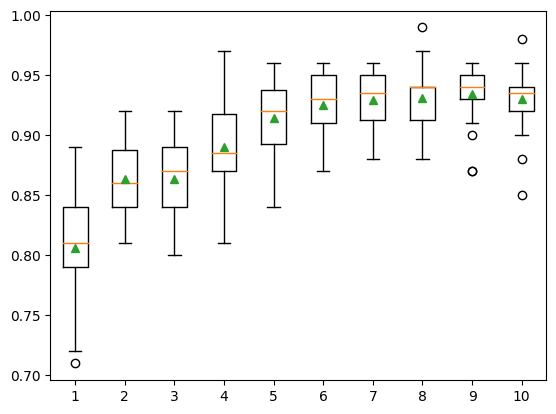

In [ ]:

# explore adaboost ensemble tree depth effect on performance
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 # explore depths from 1 to 10
 for i in range(1,11):
 # define base model
  base = DecisionTreeClassifier(max_depth=i)
 # define ensemble model
  models[str(i)] = AdaBoostClassifier(base_estimator=base)
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model and collect the results
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 # evaluate the model
 scores = evaluate_model(model, X, y)
 # store the results
 results.append(scores)
 names.append(name)
 # summarize the performance along the way
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

## **Busqueda exaustiva de hiperparametros en AdaBoost**

AdaBoost puede ser un desafío para configurar como el algoritmo, ya que muchos hiperparámetros clave que influyen en el comportamiento del modelo en los datos de entrenamiento y los hiperparámetros interactúan entre sí.

Como tal, es una buena práctica usar un proceso de búsqueda para descubrir una configuración de los hiperparámetros del modelo que funcione bien o mejor para un problema de modelado predictivo determinado. Los procesos de búsqueda populares incluyen una búsqueda aleatoria y una búsqueda en cuadrícula.

En esta sección, veremos la cuadrícula de búsqueda de rangos comunes para los hiperparámetros clave para el algoritmo AdaBoost que puede usar como punto de partida para sus propios proyectos. Esto se puede lograr utilizando la clase GridSearchCV y especificando un diccionario que asigna los nombres de los hiperparámetros del modelo a los valores de búsqueda.

<img src='https://miro.medium.com/v2/resize:fit:828/format:webp/0*yDmmJmvRowl0cSN8.png'>

Fuente: https://medium.com/@cjl2fv/an-intro-to-hyper-parameter-optimization-using-grid-search-and-random-search-d73b9834ca0a



Un ejemplo completo de búsqueda en eusastiva de los hiperparámetros clave del algoritmo AdaBoost en nuestro conjunto de datos de clasificación sintética se enumera a continuación.

In [ ]:

# example of grid searching key hyperparameters for adaboost on a classification dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=6)
# define the model with default hyperparameters
model = AdaBoostClassifier()
# define the grid of values to search
grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
# define the evaluation procedure
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
# define the grid search procedure
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy')
# execute the grid search
grid_result = grid_search.fit(X, y)
# summarize the best score and configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
# summarize all scores that were evaluated
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.813667 using {'learning_rate': 0.1, 'n_estimators': 500}
0.646333 (0.036376) with: {'learning_rate': 0.0001, 'n_estimators': 10}
0.646667 (0.036545) with: {'learning_rate': 0.0001, 'n_estimators': 50}
0.646667 (0.036545) with: {'learning_rate': 0.0001, 'n_estimators': 100}
0.647000 (0.038136) with: {'learning_rate': 0.0001, 'n_estimators': 500}
0.646667 (0.036545) with: {'learning_rate': 0.001, 'n_estimators': 10}
0.647000 (0.038136) with: {'learning_rate': 0.001, 'n_estimators': 50}
0.654333 (0.045511) with: {'learning_rate': 0.001, 'n_estimators': 100}
0.672667 (0.046543) with: {'learning_rate': 0.001, 'n_estimators': 500}
0.648333 (0.042197) with: {'learning_rate': 0.01, 'n_estimators': 10}
0.671667 (0.045613) with: {'learning_rate': 0.01, 'n_estimators': 50}
0.715000 (0.053213) with: {'learning_rate': 0.01, 'n_estimators': 100}
0.767667 (0.045948) with: {'learning_rate': 0.01, 'n_estimators': 500}
0.716667 (0.048876) with: {'learning_rate': 0.1, 'n_estimators': 10}
0.767000

**Lecturas**

- https://towardsdatascience.com/boosting-algorithms-explained-d38f56ef3f30
- https://www.geeksforgeeks.org/boosting-in-machine-learning-boosting-and-adaboost/